   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 8.0 MB/s eta 0:00:00
Cloning into 'SemEval2018-Task3'...
remote: Enumerating objects: 315, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 315 (delta 0), reused 0 (delta 0), pack-reused 312 (from 1)
Receiving objects: 100% (315/315), 681.37 KiB | 168.00 KiB/s, done.
Resolving deltas: 100% (142/142), done.
Avvio Benchmark Groq (Llama 70B)...


100%|██████████| 784/784 [33:50<00:00,  2.59s/it]




======= ACCURACY LLM GIGANTE (70B): 69.64% =======

======= REPORT DETTAGLIATO LLAMA-3.1-70B =======
ACCURACY GIGANTE: 69.64%
--------------------------------------------------

--- METRICHE PROFESSIONALI ---
                 precision    recall  f1-score   support

Non Ironico (0)       0.98      0.51      0.67       473
    Ironico (1)       0.57      0.98      0.72       311

       accuracy                           0.70       784
      macro avg       0.77      0.75      0.69       784
   weighted avg       0.82      0.70      0.69       784



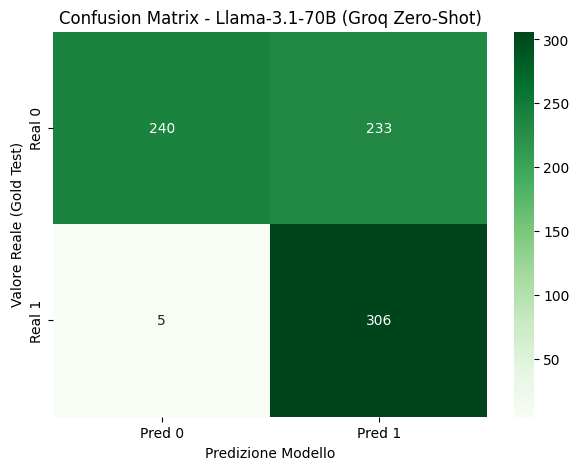


--- ERRORI DEL GIGANTE (Esempi) ---
Tweet: #NOT GONNA WIN
Real: 0 | Pred Groq: 1

Tweet: He is exactly that sort of person. Weirdo!
Real: 0 | Pred Groq: 1

Tweet: Darn, my sock joke needs fixing?
Real: 0 | Pred Groq: 1



In [ ]:
# 1. Installazione (groq)
!pip install groq

import os
from groq import Groq
import pandas as pd
import re  #strumento per cercare e cancellare pezzi di testo
from tqdm import tqdm # vedere barra di caricamento
import time

# 2. Crea il collegamento con Groq usando la chiave personale
client = Groq(api_key="Chiave_groq")

# 3. Scaricamento e pulizia
!git clone https://github.com/Cyvhee/SemEval2018-Task3.git   #scarico
path_test = 'SemEval2018-Task3/datasets/goldtest_TaskA/SemEval2018-T3_gold_test_taskA_emoji.txt'
test_df = pd.read_csv(path_test, sep='\t')
if 'tweet text' not in test_df.columns:
    test_df = pd.read_csv(path_test, sep='\t', header=None, names=['index', 'label', 'tweet text'])

def clean_tweet(text):
    text = str(text); text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) #cancello link (multiline mi serve per dire al PC di controllare bene anche se il tweet è scritto su più righe)
    text = re.sub(r'@\w+', '', text); return text.strip()   #cancello tag (e spazi bianchi)   #(text.strip rimuove tutti gli spazi vuoti inutili all'inizio e alla fine di una frase)

test_df['tweet text'] = test_df['tweet text'].apply(clean_tweet) #applica a tutti la pulizia
test_df_clean = test_df[test_df['label'].astype(str).str.contains('0|1')].copy()  #Tieni solo i tweet che hanno come etichetta 0 (non ironico) o 1 (ironico)

# 4. Benchmark con Llama-3.1-70B (Il gigante)
predictions_llm = [] #creo lista per risultati
print("Avvio Benchmark Groq (Llama 70B)...")

for text in tqdm(test_df_clean['tweet text']):   #uso tqdm per vedere quanto manca alla fine graficamente
    try:
        chat_completion = client.chat.completions.create(     # Invia il messaggio al server di Groq
            messages=[{
                "role": "user",
                "content": f"You are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).\nTweet: {text}",      #gli passo solo text non i label
            }],
            model="llama-3.3-70b-versatile",   #uso il modello da 70 miliardi di parametri
            temperature=0, # Deterministico (con temperature 0 Il modello sceglie sempre la parola con la probabilità più alta)
        )
        res = chat_completion.choices[0].message.content    # Prendi il testo della risposta dell'AI, poi metti uno se da uno, zero se da zero
        predictions_llm.append(1 if "1" in res else 0)
    except Exception as e:
        print(f"Errore sulla riga: {e}")
        predictions_llm.append(0)      # se errore, metto uno 0 per non far crashare tutto il programma

    # Groq è talmente veloce che quasi non serve sleep,
    # ma mettiamo 0.5 per sicurezza sulla quota free
    time.sleep(0.5)

# 5. Risultato
test_df_clean['prediction_llm'] = predictions_llm   #prende  predictions_llm e la incolla dentro la tabella originale (test_df_clean) come una nuova colonna
accuracy = (test_df_clean['label'].astype(int) == test_df_clean['prediction_llm']).mean() #mean per la percentuale di risposte corrette
print(f"\n\n======= ACCURACY LLM GIGANTE (70B): {accuracy:.2%} =======")
# ==============================================================================
# 6. ANALISI DETTAGLIATA
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Estraiamo i valori reali e quelli predetti da Groq
y_true = test_df_clean['label'].astype(int).values
y_pred = test_df_clean['prediction_llm'].values

print(f"\n======= REPORT DETTAGLIATO LLAMA-3.1-70B =======")
print(f"ACCURACY GIGANTE: {accuracy:.2%}")
print("-" * 50)

# 1. Classification Report (Precision, Recall, F1-Score)
print("\n--- METRICHE PROFESSIONALI ---")
print(classification_report(y_true, y_pred, target_names=['Non Ironico (0)', 'Ironico (1)']))

# 2. Matrice di Confusione (Visuale)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Real 0', 'Real 1'])
plt.title('Confusion Matrix - Llama-3.1-70B (Groq Zero-Shot)')
plt.xlabel('Predizione Modello')
plt.ylabel('Valore Reale (Gold Test)')
plt.show()

# 3. Analisi qualitativa veloce
print("\n--- ERRORI DEL GIGANTE (Esempi) ---")
errori = test_df_clean[test_df_clean['label'].astype(int) != test_df_clean['prediction_llm']].head(3)
for i, row in errori.iterrows():
    print(f"Tweet: {row['tweet text']}")
    print(f"Real: {row['label']} | Pred Groq: {row['prediction_llm']}\n")